In [24]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical # Will be used in preprocess
from PIL import Image # No longer directly used for loading, but can stay if other uses are intended
import matplotlib.pyplot as plt

# Dataset paths
train_dir = "dataset/Train/"
test_dir = "dataset/Test/"

# --- BEGIN: Data Download and Preparation ---
# This section is added to ensure the dataset exists and is correctly structured.
# It will download MNIST if not present and organize it into subdirectories.

# Load MNIST from Keras directly for simplicity
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Function to save images to the expected directory structure
def save_mnist_images(images, labels, base_dir):
    # Remove existing directory and recreate to ensure a clean slate
    if os.path.exists(base_dir):
        import shutil
        shutil.rmtree(base_dir)
    os.makedirs(base_dir, exist_ok=True) # Recreate the base directory

    for i in range(10):
        os.makedirs(os.path.join(base_dir, str(i)), exist_ok=True)

    for idx, (img, label) in enumerate(zip(images, labels)):
        img_path = os.path.join(base_dir, str(label), f'{idx}.png')
        Image.fromarray(img).save(img_path)
    print(f"Saved {len(images)} images to {base_dir}")

print("Saving MNIST dataset to local directories (ensuring clean structure)...")
save_mnist_images(x_train_raw, y_train_raw, train_dir)
save_mnist_images(x_test_raw, y_test_raw, test_dir)

# --- END: Data Download and Preparation ---

img_height, img_width = 28, 28
batch_size = 32 # Define a batch size for image_dataset_from_directory

# Load data using image_dataset_from_directory
# This function expects images to be sorted into subdirectories, one per class.
# For example: dataset/Train/0/img1.png, dataset/Train/1/img2.png
try:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        image_size=(img_height, img_width),
        color_mode='grayscale',
        batch_size=batch_size,
        shuffle=True,
        interpolation='bilinear',
        labels='inferred', # Infer labels from directory names
        label_mode='int'
    )
    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        image_size=(img_height, img_width),
        color_mode='grayscale',
        batch_size=batch_size,
        shuffle=False,
        interpolation='bilinear',
        labels='inferred',
        label_mode='int'
    )
except Exception as e:
    print(f"Error loading dataset with image_dataset_from_directory: {e}")
    print("Please ensure your dataset is organized into subdirectories for each class (e.g., 'dataset/Train/0/', 'dataset/Train/1/').")
    raise e # Re-raise the exception to stop execution if dataset is still problematic

# Preprocessing function to normalize images, flatten them, and one-hot encode labels
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0 # Normalize pixel values to [0, 1]
    # Flatten each image in the batch while preserving the batch dimension
    image = tf.reshape(image, (tf.shape(image)[0], -1)) # Reshape from (batch_size, 28, 28, 1) to (batch_size, 784)
    label = tf.one_hot(label, depth=10) # One-hot encode labels for 10 classes
    return image, label

# Apply preprocessing to both datasets
train_ds = train_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

# Convert tf.data.Dataset to NumPy arrays
x_train_list, y_train_list = [], []
for images, labels in train_ds.unbatch():
    x_train_list.append(images.numpy())
    y_train_list.append(labels.numpy())
x_train = np.array(x_train_list)
y_train = np.array(y_train_list)

x_test_list, y_test_list = [], []
for images, labels in test_ds.unbatch():
    x_test_list.append(images.numpy())
    y_test_list.append(labels.numpy())
x_test = np.array(x_test_list)
y_test = np.array(y_test_list)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


Saving MNIST dataset to local directories (ensuring clean structure)...
Saved 60000 images to dataset/Train/
Saved 10000 images to dataset/Test/
Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Train shape: (60000, 784)
Test shape: (10000, 784)


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='sigmoid', input_shape=(784,)),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4423 - loss: 1.6385

375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6740 - loss: 1.0401 - val_accuracy: 0.8888 - val_loss: 0.4080
Epoch 2/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9030 - loss: 0.3511

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9124 - loss: 0.3135 - val_accuracy: 0.9236 - val_loss: 0.2613
Epoch 3/20
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9316 - loss: 0.2388

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9365 - loss: 0.2238 - val_accuracy: 0.9369 - val_loss: 0.2079
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9467 - loss: 0.1885

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9486 - loss: 0.1770 - val_accuracy: 0.9487 - val_loss: 0.1718
Epoch 5/20
370/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9550 - loss: 0.1566

...

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9681 - loss: 0.1080 - val_accuracy: 0.9616 - val_loss: 0.1293
Epoch 8/20
366/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9721 - loss: 0.0943

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9719 - loss: 0.0945 - val_accuracy: 0.9653 - val_loss: 0.1168
Epoch 9/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9753 - loss: 0.0830 - val_accuracy: 0.9635 - val_loss: 0.1215
Epoch 10/20
366/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9785 - loss: 0.0739

375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9787 - loss: 0.0733 - val_accuracy: 0.9663 - val_loss: 0.1135
Epoch 11/20
369/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9810 - loss: 0.0660

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9808 - loss: 0.0655 - val_accuracy: 0.9685 - val_loss: 0.1071
Epoch 12/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9818 - loss: 0.0585 - val_accuracy: 0.9663 - val_loss: 0.1178
Epoch 13/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9852 - loss: 0.0510

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9846 - loss: 0.0522 - val_accuracy: 0.9712 - val_loss: 0.1027
Epoch 14/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9863 - loss: 0.0461 - val_accuracy: 0.9700 - val_loss: 0.1078
Epoch 15/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9869 - loss: 0.0421 - val_accuracy: 0.9690 - val_loss: 0.1137
Epoch 16/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9881 - loss: 0.0379 - val_accuracy: 0.9689 - val_loss: 0.1178


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


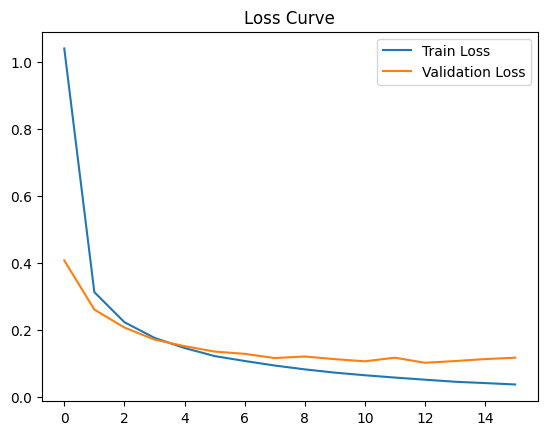

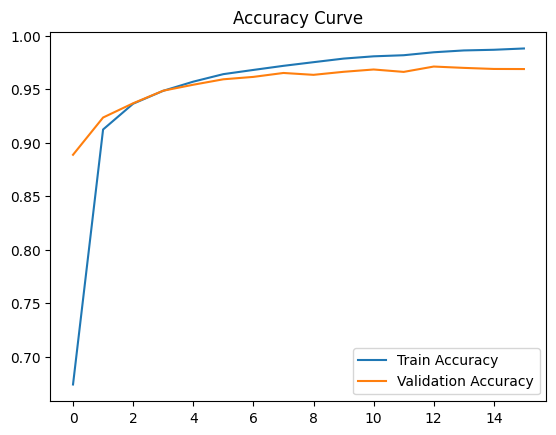

In [29]:
# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [30]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9683 - loss: 0.1186
Test Accuracy: 0.9682999849319458
